## `Filtre bilatéral`

- Le filtre bilatéral est **nonlinéaire** il lisse tout en préservant les bords, mais son calcul exact est très coûteux. 

- Les auteurs le reformulent comme une convolution gaussienne dans un espace S×R de dimension supérieure (position + intensité), suivie d’un “slicing” et d’une division (coordonnées homogènes). 

- Comme cette convolution 3D est essentiellement passe‑bas, ils proposent de la calculer sur une grille S×R fortement sous‑échantillonnée en espace et en intensité, avec un contrôle de l’erreur en termes de bande passante et de pas d’échantillonnage. 

- Le cœur de l’algorithme : construire (w, wi) sur S×R, les filtrer par une gaussienne 3D (via FFT ou noyau tronqué et séparable), puis échantillonner le volume filtré au point (p, I(p)) et normaliser. 

- Pour un même temps de calcul, cette méthode est plus précise que les approximations antérieures (Durand–Dorsey piecewise‑linear, séparabilité 1D, box itéré), surtout pour de grands noyaux spatiaux. 

- Ils montrent des temps de l’ordre de la seconde pour des images 2 Mpx avec un résultat visuellement proche de l’évaluation exacte qui prend plusieurs dizaines de minutes, et l’extension est naturelle aux images couleur et au cross‑bilateral.

- Il est très efficace pour de nombreuses tâches en vision par ordinateur et en infographie, mais son calcul exact est coûteux, d’où de nombreuses méthodes d’accélération dont la précision reste mal connue. 

In [ ]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

`Filtrage linéaire Gaussien`.  
L’opération de filtrage la plus élémentaire est gaussien, qui a tendance à adoucir ou flouter les contours.

In [59]:
# Image size.
n = 256*2

Load an image.

(512, 512)


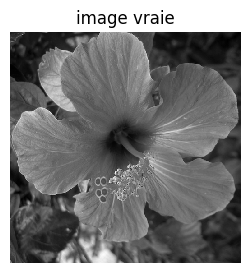

In [61]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)
from skimage.transform import rescale
f0_small = rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(3, 3))
imageplot(clamp(f0),'image vraie')

A filtre Gaussien de variance  $\sigma$ vu comme : 
 - $ \large \Gg_\sigma(f)(x) = \frac{1}{Z} \sum_y G_\sigma(x-y) f(y)$ 
 - où $ Z = \sum_y G_\sigma(y)$ avec un kernel Gaussien définit comme : $ G_\sigma(x) = \Large \frac{1}{2\pi\sigma^2} e^{- \Large \frac{||{x}||^2}{2\sigma^2}}$

    - Le poids du pixel x est défini par la gaussienne  $G_{\sigma}(x - y)$, 
    - où $\sigma$ est un paramètre qui définit la taille du voisinage. 
    - l'influence d'un pixel sur un autre ne dépend que de leur distance dans l'image.

Le coût en opérations d’une convolution dépend de la façon dont on la calcule. 

`Domaine spatial` : 
- pour une image de N pixels et un noyau gaussien de largeur caractéristique $\sigma_x$, 
- le noyau a une taille effective proportionnelle à $\sigma_x^2$ en 2D.
- donc la convolution directe a une complexité $O(N\sigma_x^2$) : 
- pour chaque pixel, on fait une somme sur tous les coefficients du noyau.

`Domaine de Fourier` : 
- on utilise le théorème de convolution : 
- la convolution dans l’espace = produit point à point dans le domaine de Fourier.
- se fait en 3 FFT (signal, noyau, inverse) chacune en une complexité $O(NlogN)$ et totale .

__`Conséquence pratique :`__
- pour des petits noyaux $(3×3,5×5)$, la méthode spatiale est plus rapide (car $\sigma_x^2$ est petit).
- pour des noyaux très larges (flous gaussiens très lissés, filtres longue portée), 
- le coût $O(N\sigma_x^2)$ devient énorme et la méthode par FFT $O(NlogN)$ devient avantageuse.
- pour simplifier considérons le domaine de Fourier (implique des conditions aux bords périodiques).
- définissons une gaussienne centrée dans le coin supérieur gauche, correspondant au point d’indice nul pour la FFT.

In [34]:
H, W = f0.shape
# X,Y : grilles 2D centrées au coin (0,0)
X, Y = np.meshgrid(np.arange(W), np.arange(H))
GaussianFilt = lambda s: np.exp(-(X**2 + Y**2) / (2 * s**2))

In [62]:
tx = np.concatenate((np.arange(0,n/2), np.arange(-n/2,0)))
[Y,X] = np.meshgrid(tx, tx)
GaussianFilt = lambda s: np.exp(-(X**2 + Y**2) / (2 * s**2))

Afficher un exemple Gaussien recentré

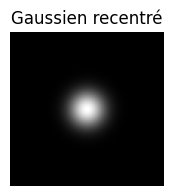

In [64]:
plt.figure(figsize=(2,2))
imageplot(np.fft.fftshift(GaussianFilt(40)),'Gaussien recentré')

- Définir un raccourci pour effectuer un filtrage gaussien linéaire dans le domaine de Fourier. 
- Cette fonction est capable de traiter en parallèle un bloque 3D $F$ filtrant chaque tranche $|F(:,:,i)|$. 

In [65]:
Filter = lambda F, s: np.real(np.fft.ifft2(np.fft.fft2(F) * np.fft.fft2(GaussianFilt(s))))

Example of filtering $ \Gg_\si(f_0) $.

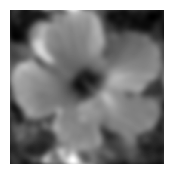

In [67]:
plt.figure(figsize=(2,2))
imageplot(Filter(f0,10))

### __`Exercice 1`__
Afficher le filtrage $\Gg_\sigma(f_0)$ avec une augmentation de la taille $\sigma$.

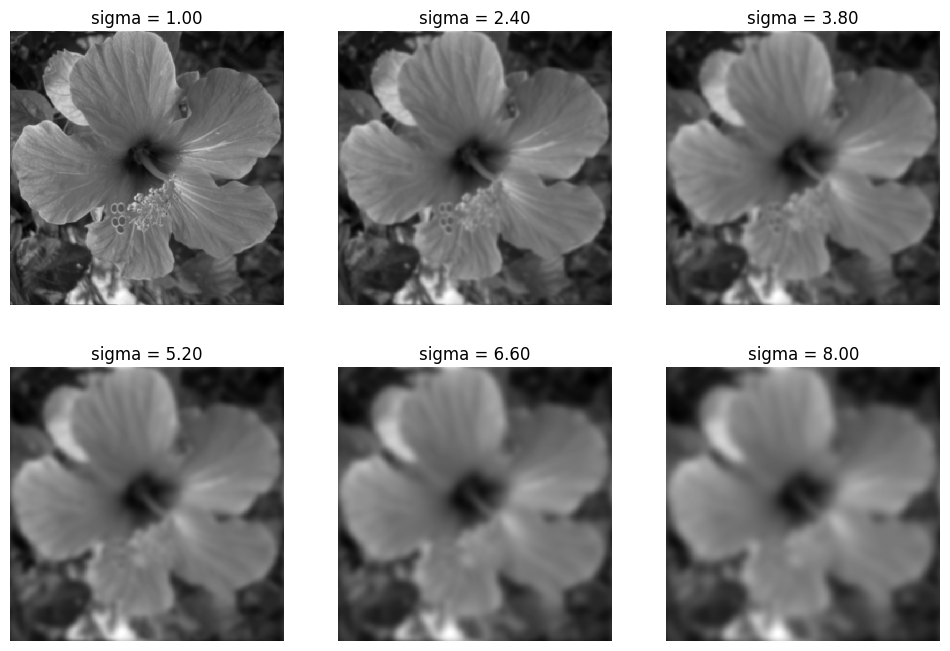

In [70]:
import matplotlib.pyplot as plt
import numpy as np

sig_list = np.linspace(1,8,6)
ncols = 3
nimgs = len(sig_list)
nrows = int(np.ceil(nimgs / ncols))

plt.figure(figsize=(12,8))

for i, sig in enumerate(sig_list):
    imageplot(Filter(f0,sig),f"sigma = {sig:.2f}", [nrows, ncols, i+1])
#plt.show()

### `Filtre bilatéral`
Le filtre bilatéral possède plusieurs qualités qui expliquent son succès :
 - L’idée essentielle du **filtre** bilatéral est que, pour qu’un pixel puisse en influencer un autre, il doit non seulement se trouver à proximité spatiale, mais aussi avoir une valeur similaire. 

 - Chaque pixel est remplacé par une moyenne de ses voisins, cet aspect est important car il facilite l’intuition sur son comportement, son adaptation à des besoins spécifiques, ainsi que sa mise en œuvre.

 `Il dépend de 2 paramètres qui indiquent la taille et le contraste des structures à préserver`.
 - Il peut être utilisé de manière non itérative rendant le réglage des paramètres plus simple, puisque leur effet ne s’accumule pas au fil de plusieurs itérations.

 - Il peut être calculé à une vitesse interactive, même sur de grandes images, grâce à des schémas numériques efficaces et même en temps réel si du matériel graphique est disponible.

 - Le filtre bilatéral est un filtre **spatialement** variant qui préserve mieux les contours que le filtre gaussien classique, 
 - il est controllé par deux paramètres:  
   - une largeur spatiale $\large \sigma_x$ lorsqu'elle augmente, le filtre converge vers une convolution gaussienne, 
   - une largeur d'intensité $\large \sigma_v$ qui permet de lisser des structures de plus grande taille. 
$$\large \mathcal{B}_{\sigma_x,\sigma_v}(f)(x) = \frac{1}{Z_x} \sum_y G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y))\, f(y)$$
`1°) L’image d’entrée` $f$ `à la position` $x$ : 
Fonction image, qui à chaque pixel $x$ associe une intensité $f(x)$ (en niveaux de gris .i.e) 
- $x$ : position du pixel central que l’on filtre (un vecteur 2D en pratique, type $(i,j)$). 
- $y$ : parcourt les pixels du voisinage de $x$ (typiquement dans une fenêtre $(2k+1)×(2k+1)$).
- but : produire une image $B_{σx,σv}(f)$ où $x$ est un lissage des $f(y)$ autour de $x$, préservant les contours.
`2°) Le noyau spatial` $G_{\sigma}x (x−y)$ `et` ${\sigma}x$
- typiquement $G_\sigma(x - y) = \Large e^{- \Large \frac{||{x - y}||^2}{2\sigma^2}}$
- rôle pondérer les pixels $y$ fonction de leur distance à $x$, plus $y$ est loin de $x$ plus son poids diminue.
- $\sigma_x$ (souvent noté $\sigma_s$ ) le paramètre spatial.
  - petit $\sigma_x$ on ne prend en compte que les voisins très proches, donc lissage très local.
  - grand $\sigma_x$ on considère un voisinage plus large, donc lissage de structures de grande taille 
`3°) Le noyau de gamme photométrique, ou en intensité)` $G_{\sigma_v}(f(x)-f(y)) \text{ et } \sigma_v $
- $G_{\sigma_v}(f(x)-f(y))$ gaussienne dite de gamme (ou photométrique, ou en intensité).
- Typiquement : $G_{\sigma_v}(f(x)-f(y)) = \exp({- \Large \frac{({f(x) - f(y)})^2}{2\sigma^2}})$
- rôle pondérer les pixels $y$ selon la différence d’intensité entre $f(x)$ et $f(y)$
  - si $f(y)$ est proche de $f(x)$, le poids est proche de 1.
  - si f(y) est très différent de $f(x)$, le poids devient très faible.
- $\sigma_v$ (souvent noté $\sigma_r$) : paramètre de gamme / radiométrique.
  - petit $\sigma_v$ : on ne moyenne qu’avec des pixels de valeur proche de $f(x)$ → on évite de mélanger des régions séparées par un contour, donc on préserve mieux les bords.

  - grand $\sigma_v$ : la gaussienne de gamme devient plus plate, donc presque constante sur l’intervalle de valeurs de l’image ; le filtre se rapproche alors d’un flou gaussien classique (pondération surtout spatiale). 
`4°) La normalisation` $Z_x$
$$\large Z_x = \sum_y G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y))$$
  - $Z_x$ : terme de normalisation qui assure que la somme des poids vaut 1 au point x.
  - concrètement, $\frac{1}{Z_x}$ garantit que $B_{\sigma_v,\sigma_v} (f)(x)$ est une moyenne pondérée des $f(y)$ du voisinage.
  - sans $Z_x$, l’amplitude peut varier d’un pixel à l’autre fonction du nombre, de la “force” des voisins compatibles.
`5°) Interprétation globale`
 - Pour un pixel $x$, chaque voisin $y$ contribue à la valeur filtrée avec un poids.
$$\omega(x,y) = G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y)) $$
- le poids est grand si : 
   - $y$ est proche de $x$ dans l’espace (même région), 
   - et si $f(y)$ est proche de $f(x)$ en intensité (même “région photométrique”).
- il est petit si le voisin est loin ou de valeur très différente (de l’autre côté d’un bord par exemple).
Ainsi, le filtre lisse le bruit à l’intérieur des régions homogènes, mais évite de mélanger des régions séparées par un contour marqué.

### `Filtre bilatéral par empilement`

Une implémentation directe du filtre bilatéral dans le domaine spatial nécessite $O(N \sigma_x^2)$ opérations, où 
 - $N$ est le nombre de pixels exploite le fait que, 
   - $\large \forall$  pixels $x$ ayant la même valeur $v = f(x)$, 
   - le filtre bilatéral peut s’écrire comme un ratio de convolutions :$\Large \frac{\big[ G_{\sigma_x} * (f \cdot W_v) \big](x)}{\big[ G_{\sigma_x} \star W_v \big](x)}$
   - où la carte de poids est $W_v(x) = G_{\sigma_v}(v - f(x))$ 
 - Au lieu de calculer toutes les cartes de poids $W_v$ pour toutes les valeurs de pixels possibles $v$, 
 - On considère un sous‑ensemble $\{v_i\}_{i=1}^p$ de $p$ valeurs et on calcule les poids $\{W_{v_i}\}_i$.
 - À partir des convolutions, on obtient les cartes $\{F_{v_i}\}_i$, combinées pour fournir une approximation de $\mathcal{B}_{\sigma_x,\sigma_v}(f)$. 
 - Le temps de calcul est de $O(p\,N\log N)$ dans le domaine de Fourier et de $O(p\,N\sigma_x^2)$ dans le domaine spatial. 

 - Valeur de $\sigma_x$ : largeur spatiale, lorsqu'il augmente, le filtre converge vers une convolution gaussienne,
 - Valeur de $\sigma_v$: en largeur d'intensité $\large \sigma_v$ permet de lisser des structures de plus grande taille
 - La complexité de l'algorithme est proportionnel au nombre  $p$  de couches 

In [150]:
sx = 5
sv = .2
p = 10

La fonction ci-dessous crée un stack de cartes de poids  $W_{v_i}$ de taille $(n, n, p)$.

In [144]:
print(f"f0.shape : {f0.shape}, f0[:,:,None].shape : {f0[:,:,None].shape}")
x = np.array([[[1,2]]]) 
print(f"x_init.shape : {f0.shape}")
x = np.repeat(f0[:,:,None], 2, axis=2)
print(f"x.shape : {x.shape} \n{x[0].shape}")

f0.shape : (512, 512), f0[:,:,None].shape : (512, 512, 1)
x_init.shape : (512, 512)
x.shape : (512, 512, 2) 
(512, 2)


 :::
 - _`Construire le poids d'une couche`_ $ \{ W_{v_i} \}_i $ pour $v_i$ uniformément distribué entre [0,1]
 - _`Définir la carte de poids`_ $W_{v_i}(x) = G_{\sigma_v} (v_i −f(x))$,$.
 :::
 :::
__1. Rappel de la définition__
  - On veut, pour chaque $v_i \in [0,1]$, 
  - définir la carte de poids $W_{v_i}(x) = G_{\sigma_v} (v_i −f(x))$,
     - où $G{\sigma_v}$ est la gaussienne en intensité (paramètre $\sigma_v$ ), 
     - et $f(x)$ l’image normalisée dans $[0,1]$.
 - On regroupe ensuite toutes ces cartes dans un tenseur 3D W de taille $(n,n,p)$ 
   - si l’image fait $n×n$ et qu’on prend p valeurs $v_i$) :
   - $W[:,:,i]$ correspond à $W_{v_i}$
:::   

In [142]:
gaussian = lambda x, sigma: np.exp(-x**2 / (2*sigma**2))

def WeightMap(f0, sv, p):
    n, m = f0.shape
    assert n == m
    # contient toutes les valeurs normalisées de v_i uniformemément sur [0,1]
    v = np.linspace(0,1,p) / (p - 1)               # (0:p-1)/(p-1)
    v = v.reshape(1, 1, p)                         # [1, 1, p]
    # construit une stack 3D pour chaque i entre 0 et p-1, f0_rep est une copie de l’image f0.                                               
    f0_rep = np.repeat(f0[:, :, None], p, axis=2)  # [n, n, p]
    # sert à fabriquer un tenseur (n,n,p) à partir d’un vecteur v de taille (1,1,p). 
    v_rep  = np.repeat(np.repeat(v, n, axis=0), n, axis=1)  # [n, n, p]
    return gaussian((f0_rep - v_rep), sv)

Calculer le poids de la Map pour chaque $|W(:,:,i)|$ est la map $W_{v_i}$ associé à la valeur de chacun des pixels $ v_i $.

In [149]:
W = WeightMap(f0, sv,p)

Cette pile sert ensuite à pondérer l'image dans chaque “couche” $v_i$ , 
 - typiquement pour construire une approximation du filtre bilatéral travaillant dans l’espace (x,v) 
 - on applique un flou spatial sur chaque couche puis on reconstruit.
 - concrètement, l’étape suivante typique est de calculer pour chaque i :
 $$F_{v_i}(x)=(G{\sigma_x}⋆(f_0⋅W_{v_i}))(x)$$
 $$Z_{v_i}(x)=(G_{\sigma_x}⋆W_{v_i})(x)$$

__Exercise 2__

Display several weights $ W_{v_i} $.

In [ ]:
## Insert your code here.

Shortcut to compute the bilateral stack $\{ F_{v_i} \}_i $.

In [ ]:
bileteral_stack_tmp = lambda f0, sx, W: Filter(W.*repmat(f0, [1 1 p]), sx) ./ Filter(W, sx)
bileteral_stack = lambda f0, sx, sv: bileteral_stack_tmp(f0, sx, WeightMap(f0, sv))

Compute the bilateral stack $\{ F_{v_i} \}_i $.

In [ ]:
F = bileteral_stack(f0, sx, sv)

__Exercise 3__

Display several stacks $F_{v_i}$.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Destacking corresponds to selecting a layer $ I(x) \in \{1,\ldots,p\} $ at each pixel.
$$f_I(x) = F_{ v_{I(x)} }(x). $$


Shortcut for de-stacking using a set of indexes.

In [ ]:
[y, x] = meshgrid(1: n, 1: n)
indexing = lambda F, I: F(I)
destacking = lambda F, I: indexing(F, x + (y-1)*n + (I-1)*n^2)

The simplest reconstruction method performs the destacking using the
nearest neighbor value:
$$ I(x) = \uargmin{ 1 \leq i \leq p } \abs{f(x)-v_i}.  $$


Shortcut for performing de-stacking by nearest neighbor interpolation.

In [ ]:
bilateral_nn = lambda f0, sx, sv: destacking(bileteral_stack(f0, sx, sv), round(f0*(p-1)) + 1)

Display.

In [ ]:
fNN = bilateral_nn(f0, sx, sv)

imageplot(fNN)

A better reconstruction is obtained by using a first order linear
interpolation to perform the destacking.
$$ \Bb_{\si_x,\si_v}(f)(x) \approx (1-\la(x))f_{I(x)}(x)  + \la(x) f_{I(x)+1}(x)$$
where $I(x)$ and $\la(x)$ are defined as
$$ f(x) = (1-\la(x)) v_{I(x)} + \la(x) v_{I(x)+1} \qwhereq \la(x) \in [0,1).  $$


Shortcut for the linear interpolation reconstruction.

In [ ]:
frac = lambda x: x-floor(x)
lininterp = lambda f1, f2, Fr: f1.*(1-Fr) + f2.*Fr
bilateral_lin1 = lambda F, f0: lininterp(destacking(F, clamp(floor(f0*(p-1)) + 1, 1, p)), ...
                                  destacking(F, clamp(ceil(f0*(p-1)) + 1, 1, p)), ...
                                  frac(f0*(p-1)))
bilateral_lin = lambda f0, sx, sv: bilateral_lin1(bileteral_stack(f0, sx, sv), f0)

__Exercise 4__

Compare nearest-neighbor and linear destacking.

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.

__Exercise 5__

Study the influence of $\sigma_x$ on the filter, for a fixed
$\sigma_v=0.2$.

In [ ]:
solutions.exo5()

In [ ]:
## Insert your code here.

__Exercise 6__

Study the influence of $\sigma_v$ on the filter, for a fixed
$\sigma_x=8$.

In [ ]:
solutions.exo6()

In [ ]:
## Insert your code here.

Note that this stack implementation of the bilateral filter can be quite
inacurate, in particular if $p$ is small. A more precise fast
implementation is described in:


_A Fast Approximation of the Bilateral Filter using a Signal Processing Approach_,
Sylvain Paris and Fr do Durand,
International Journal of Computer Vision (IJCV'09)

Denoising using the Bilateral Filter
------------------------------------
The first basic application of the bilateral filter is for denoising.
It performs a filtering that respects edges.


Noise level.

In [ ]:
mu = .05

Create a noisy image $f = f_0 + w$ where $w$ is a Gaussian white noise of variance $\mu^2$.

In [ ]:
f = f0 + randn(n, n)*mu

Display the noisy image.

In [ ]:
imageplot(clamp(f))

Perform denoising using the bilateral filter.

In [ ]:
sx = 4; sv = .2

imageplot(clamp(bilateral_lin(f, sx, sv)))

__Exercise 7__

Compute the optimal parameter $(\sigma_x,\sigma_v)$ to maximize the
SNR between $f_0$ and the filtered image. Record the optimal denoising
result in |fOpt|.

In [ ]:
solutions.exo7()

In [ ]:
## Insert your code here.

Display optimal denoising.

In [ ]:
imageplot(clamp(fOpt), ['Bilateral, SNR = ' num2str(snr(f0, fOpt), 3) 'dB'])

__Exercise 8__

Compare with translation invariant wavelet thresholding.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.

Detail Enhancement
------------------
The bilateral filters is able to remove fine scale details (noise,
textures) and retain only the cartoon content of the image (shape edges).


Set up parameters $\si_x,\si_v$.

In [ ]:
sx = 4
sv = .2

Performm the filtering to obtain the base layer $ f_1 = \Bb_{\si_x,\si_v}(f_0) $.

In [ ]:
f1 = bilateral_lin(f0, sx, sv)

Compute the detail layer $ r = f_0 - f_1 $.

In [ ]:
r = f0 - f1

Display the base layer.

In [ ]:
imageplot(f1)

Display the residual.

In [ ]:
imageplot(r)

__Exercise 9__

Perform detail boosting by enhancing the detail layer.
For instance use various non-linear remapping of the intensities such as
$ f_1 + \ga r^\al $ for some values of $\ga \geq 1$ and $\al>0$.

In [ ]:
solutions.exo9()

In [ ]:
## Insert your code here.

__Exercise 10__

Extend the bilateral filter for color images.

In [ ]:
solutions.exo10()

In [ ]:
## Insert your code here.

High Dynamic Range Tone Mapping
-------------------------------
Tone mapping corresponds to compressing the contrast of an image that
contains a large dynamic range, in order to be viewable on
a low dynamic range display.


Load a high dynamic range image.

In [ ]:
addpath('toolbox_additional/ ')
name = 'memorial'
f = load_hdr([name '.hdr'])
p = min(size(f, 1), size(f, 2))
f = rescale(f(1: p, 1: p, : ))
f = rescale(clamp(image_resize(f, n, n)))

The pixel values can take very large value and leads to over exposition
(saturation) if displayed with a limited range (clamping of the values).

In [ ]:
imageplot(min(f, 1e-4))

Selecting a higher threshold leads to less saturation but more region
being under exposed (dark).

In [ ]:
imageplot(min(f, 1e-3))

A simple way to process a color image is to perform a change of color
space and to process only the intensity channel.


For instance one can use a HSV color space and process the intensity channel $f_V$.

In [ ]:
fhsv = rgb2hsv(f)
fV = fhsv(: , : , 3)

Shortcut the reconstruct the image using a modified V channel.

In [ ]:
color_recompose = lambda fV: hsv2rgb(cat(3, fhsv(: , : , 1: 2), rescale(fV)))

color_recompose = @(fV1)f.*repmat(fV1./fV, [1 1 3]);


Global tone mapping corresponds to applying a fixed non-linear mapping $\phi$ to
all the pixel to compress the range by displaying $\phi(f_V)$.


A polpular contrast modification is the $\gamma$ correction, that uses
$ \phi(t) = (t+\epsilon)^\al $ for a small $ \epsilon>0 $
and $\al \in (0,1]$.

In [ ]:
epsilon = 1e-5
alpha = 0.1
imageplot(color_recompose((fV + epsilon).^alpha))

__Exercise 11__

Try several tone mapping operators, such as for instance
$$ \phi_1(t)=\frac{t}{t+\epsilon} \qandq \phi_2(t) = \log(t+\epsilon) $$

In [ ]:
solutions.exo11()

In [ ]:
## Insert your code here.

Global tone mapping tends to destroy fine scale details.
A local tone mapping operator decompose the logarithm
$$ F_V = \frac{ \log(f_V + \epsilon)-a }{ b-a } $$
of $f_V$
into a base cartoon layer and a textured layer, and only
compress the base layer. Here $a$ and $b$ are compute to ensure
that $F_V \in [0,1]$.


Compute the rescaled logarithm layer $F_V$.

In [ ]:
epsilon = 1e-5
FV = log(fV + epsilon)
a = min(FV(: )); b = max(FV(: ))
FV = (FV-a)/ (b-a)

The base layer is defined as
$ B_V = \Bb_{\si_x,\si_v}(F_V) $.

In [ ]:
sx = 5; sv = .02
FV1 = bilateral_lin(FV, sx, sv)

The tone mapped intensity image is defined as
$$ \tilde f_V = e^{ ( \ga B_V + F_V - B_V )(b-a)+a  } - \epsilon $$
where $ \ga \in (0,1] $ is the compression factor.
For $\ga=1$, one has $\tilde f_V = f_V$.



Display the filtered layer over the log domain.

In [ ]:
imageplot(FV1)

Display the residual over the log domain.

In [ ]:
imageplot(FV-FV1)

__Exercise 12__

Compute the tone mapped image using $\tilde f_V$.
Test with several value of $\ga,\epsilon, \si_x,\si_v$.

In [ ]:
solutions.exo12()

In [ ]:
## Insert your code here.